<a href="https://colab.research.google.com/github/AkankshaB123/ML/blob/main/WeatherHistory_LinearRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# =============================================================================
#  Multiple Linear Regression
# =============================================================================

# Importing the libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# =============================================================================
# # Importing the dataset
# =============================================================================

weather_data = pd.read_csv('/content/sample_data/weatherHistory.csv')
weather_data.head(3)

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.


# EDA

In [4]:
All=weather_data.describe(include='all')# describes allnumerical and  categorical data
Cat=weather_data.describe(include=['O'])# describes all  categorical data
Cor=weather_data.select_dtypes(include=np.number).corr()
data_set=weather_data.iloc[:,[0,2,3,4,5,8]]
Cor_s=data_set.select_dtypes(include=np.number).corr()

<Axes: xlabel='Temperature (C)', ylabel='Humidity'>

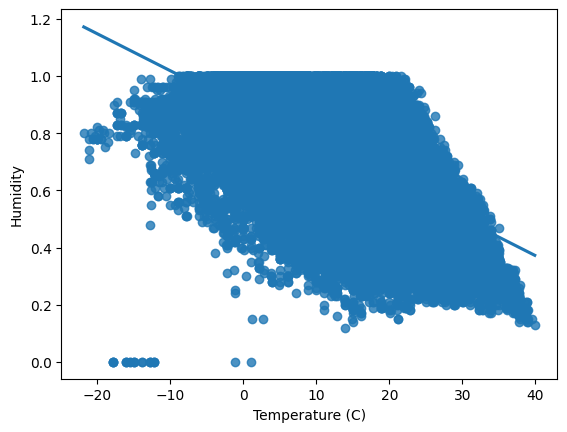

In [5]:
# plotting a scatter plot between temp and humdity
sns.regplot(x=data_set["Temperature (C)"], y=data_set["Humidity"])

In [6]:
# =============================================================================
# Outlier Indetification and Removal based on Z-Score
# =============================================================================

outliers=[]
def detect_outlier(data_1):

    threshold=3
    mean_1 = np.mean(data_1)
    std_1 =np.std(data_1)


    for y in data_1:
        z_score= (y - mean_1)/std_1
        if np.abs(z_score) > threshold:
            outliers.append(y)
    return outliers
outlier_data = detect_outlier(data_set["Humidity"])
print (outlier_data)

[0.14, 0.14, 0.14, 0.13, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.12, 0.14]


<Axes: xlabel='Temperature (C)', ylabel='Humidity'>

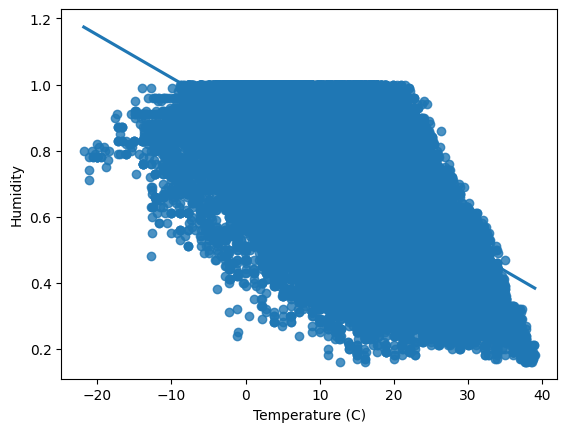

In [7]:
#Removing the Outliers
data_set_clean = data_set[data_set["Humidity"]>0.15]

sns.regplot(x=data_set_clean["Temperature (C)"], y=data_set_clean["Humidity"])

In [8]:
# =============================================================================
# Creating the Independendent and Dependent Data Sets
# =============================================================================
y= data_set_clean.iloc[:,[2]] # Dependent Data
X= data_set_clean.iloc[:,[1,3,4]] #Feature Data

X1= pd.get_dummies(X, columns =['Precip Type'])

In [9]:
# =============================================================================
# # Splitting the dataset into the Training set and Test set
# =============================================================================
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X1, y, test_size = 0.2, random_state = 0)

In [10]:
# Fitting Multiple Linear Regression to the Training set
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train, y_train)

regressor.coef_
regressor.intercept_

array([4.36937561])

In [11]:
# Predicting the Test set results
y_pred = regressor.predict(X_test)
y_pred_data=pd.DataFrame(y_pred)

regressor.score(X_train,y_train)
regressor.score(X_test,y_test)

#Root Mean Square Error
from sklearn import metrics
import math
print(math.sqrt(metrics.mean_squared_error(y_test, y_pred)))

1.0828963217076641


In [13]:
# =============================================================================
# #Model Statistics
# =============================================================================

#Adding Intercept term to the model
X_train=sm.add_constant(X_train)
X_test=sm.add_constant(X_test)

# Convert boolean columns to integer type for statsmodels
for col in ['Precip Type_rain', 'Precip Type_snow']:
    if col in X_train.columns and X_train[col].dtype == bool:
        X_train[col] = X_train[col].astype(int)
    if col in X_test.columns and X_test[col].dtype == bool:
        X_test[col] = X_test[col].astype(int)


#Converting into Dataframe
X_train_d=pd.DataFrame(X_train)

#Printing the Model Statistics
model = sm.OLS(y_pred,X_test).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 6.304e+34
Date:                Sun, 19 Jul 2026   Prob (F-statistic):               0.00
Time:                        15:34:58   Log-Likelihood:             6.2008e+05
No. Observations:               19283   AIC:                        -1.240e+06
Df Residuals:                   19278   BIC:                        -1.240e+06
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
============================================================================================
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                        4.3694   2.77e-16   1.58e+16      0.000       4.369       4.369
Apparent Temperature (C)     0.8505   2.65e-18   3.21e+17      0.000       0.851       0.851
Humidity                    -2.7424   1.23e-16  -2.22e+16      0.000      -2.742      -2.742
Precip Type_rain             0.3868   2.55e-16   1.51e+15      0.000       0.387       0.387
Precip Type_snow             0.0491   2.63e-16   1.87e+14      0.000       0.049       0.049
==============================================================================
Omnibus:                      697.128   Durbin-Watson:                   1.371
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              764.864
Skew:                          -0.480   Prob(JB):                    8.17e-167
Kurtosis:                       2.830   Cond. No.                         362.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [16]:
#Checking the VIF Values
from statsmodels.stats.outliers_influence import variance_inflation_factor
# Calculate VIF values for X_train if it has columns to calculate for
if X_train.shape[1] > 0:
    print([variance_inflation_factor(X_train.values, j) for j in range(X_train.shape[1])])

# Conditionally drop 'Precip Type_snow' if it exists
if "Precip Type_snow" in X_train.columns:
    New_X_train = X_train.drop("Precip Type_snow", axis = 1)
else:
    New_X_train = X_train.copy() # If it doesn't exist, use X_train as is

if "Precip Type_snow" in X_test.columns:
    New_X_test = X_test.drop("Precip Type_snow", axis = 1)
else:
    New_X_test = X_test.copy() # If it doesn't exist, use X_test as is


regressor.fit(New_X_train, y_train)



model1 = sm.OLS(y_pred, New_X_test).fit() # Use New_X_test for fitting the new model
model1.summary() # Display summary for model1

[np.float64(35.542338526655094), np.float64(2.223147900817263), np.float64(1.622208724020128), np.float64(1.4856823089408606)]


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 4.636e+10
Date:                Sun, 19 Jul 2026   Prob (F-statistic):               0.00
Time:                        15:37:21   Log-Likelihood:                 81537.
No. Observations:               19283   AIC:                        -1.631e+05
Df Residuals:                   19279   BIC:                        -1.630e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
============================================================================================
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                        4.4167      0.000    2.9e+04      0.000       4.416       4.417
Apparent Temperature (C)     0.8504   3.54e-06    2.4e+05      0.000       0.850       0.850
Humidity                    -2.7433      0.000  -1.65e+04      0.000      -2.744      -2.743
Precip Type_rain             0.3409   9.62e-05   3542.181      0.000       0.341       0.341
==============================================================================
Omnibus:                    32970.332   Durbin-Watson:                   2.011
Prob(Omnibus):                  0.000   Jarque-Bera (JB):         20203815.240
Skew:                         -12.199   Prob(JB):                         0.00
Kurtosis:                     159.687   Cond. No.                         130.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [17]:
#Storing Coefficients in DataFrame along with coloumn names
coefficients = pd.concat([pd.DataFrame(X_train_d.columns),pd.DataFrame(np.transpose(regressor.coef_))], axis = 1)
